In [46]:
import matplotlib.pyplot as plt
import numpy as np
from abc import ABC, abstractmethod
import random
import math

DATA_FILE = "histograms/baseline.txt"

In [47]:
class RNG(ABC):
    @abstractmethod
    def sample(self):
        pass

class UniformRNG(RNG):
    def __init__(self, low, high):
        self.low = low
        self.high = high
        self.rng = np.random.default_rng()
    
    def sample(self):
        return self.rng.uniform(self.low, self.high)

class NormalRNG(RNG):
    def __init__(self, mean, min, max):
        self.mean = mean
        self.stddev = (max - min) / 4
        self.min = min
        self.max = max
        self.rng = np.random.default_rng()
    
    def sample(self):
        sample = self.rng.normal(self.mean, self.stddev)
        if sample < self.min or sample > self.max:
            return self.sample()
        return sample

class MultiModalRNG(RNG):
    def __init__(self, normal_rngs, weights):
        self.normal_rngs = normal_rngs
        self.weights = weights
        self.rng = np.random.default_rng()
    
    def sample(self):
        choice = self.rng.choice(len(self.normal_rngs), p=self.weights)
        return self.normal_rngs[choice].sample()

In [48]:
class CollocationCost:
    def __init__(self, avg_carry_over, carry_over_freq):
        """
        Args:
            avg_carry_over (float): Average carry over CPU usage for epoch with carry over
            carry_over_freq (float): Frequency of carry over occurrences (0.0 - 1.0)
        """
        self.avg_carry_over = avg_carry_over
        self.carry_over_freq = carry_over_freq

    def __str__(self):
        return f"CollocationCost(carry_over_freq={(self.carry_over_freq * 100):.2f}%, avg_carry_over={self.avg_carry_over:.2f}%)"


class Histogram:
    def __init__(self, bin_size):
        self.total_weight = 0
        self.bins = [0 for _ in range(int(100 / bin_size))]
        self.bin_size = bin_size

    def set_weight(self, bin_index, weight):
        if bin_index < 0 or bin_index >= len(self.bins):
            raise ValueError("Invalid bin index")

        self.total_weight -= self.bins[bin_index]
        self.bins[bin_index] = weight
        self.total_weight += weight

    def draw(self):
        x = [i * self.bin_size for i in range(len(self.bins))]
        heights = [w / self.total_weight for w in self.bins]
        plt.bar(x, heights, width=self.bin_size, align="edge", edgecolor="black", linewidth=1.5)
        plt.xlabel("CPU")
        plt.ylabel("Probability")
        plt.title("Histogram")
        plt.xlim(min(x), max(x) + self.bin_size)
        plt.xticks([i * 10 for i in range(int(100 / 10) + 1)])
        plt.show()

    def sample(self):
        r = random.randint(1, self.total_weight)
        cumulative = 0
        for i, weight in enumerate(self.bins):
            cumulative += weight
            if r <= cumulative:
                return math.ceil(i * self.bin_size + (self.bin_size / 2))
        return 100

    def export(self, filename):
        with open(filename, "w") as f:
            f.write(f"bucket_size: {self.bin_size}\n")
            for weight in self.bins:
                f.write(f"{weight}\n")

    @staticmethod
    def import_from(filename):
        hist = None
        with open(filename, "r") as f:
            bin_index = 0
            for line in f:
                if line.startswith("bucket_size: "):
                    bucket_size = float(line.strip().split(" ")[1])
                    hist = Histogram(bucket_size)
                else:
                    if hist is None:
                        return None

                    weight = int(line.strip())
                    hist.set_weight(bin_index, weight)
                    bin_index += 1
        return hist

    @staticmethod
    def generate(bin_size, samples=20, rng=None):
        if rng is None:
            rng = UniformRNG(0, 100)

        hist = Histogram(bin_size)
        for _ in range(samples):
            usage = rng.sample()
            if usage >= 100:
                bin_index = int(100 / bin_size) - 1
            else:
                bin_index = int(usage / bin_size)
            hist.bins[bin_index] += 1
            hist.total_weight += 1
        return hist

    @staticmethod
    def collocate(*hists, simulated_epochs=10_000):
        """
        For each epoch, pick a random CPU usage from different hists and add them together, producing
        a datapoint for the new histogram. If combined usage exceeds 100%, carry over the excess to the next epoch.
        Assumes histograms are given the same priority on the CPU, so the histogram using the most CPU will suffer
        have the most carry over cost.

        Returns:
            Tuple of (Histogram, [CollocationCost, ...]). Histogram is the predicted utilization if processes are collocated.
            CollocationCost holds the average carry over CPU usage across all epochs and frequency of carry overs.
            Each input histogram suffers its own cost.
        """
        max_bin_size = max([hist.bin_size for hist in hists])
        result = Histogram(max_bin_size)

        carry_over_sum = [0 for _ in hists]
        carry_over_count = [0 for _ in hists]
        carry_over = [0 for _ in hists]
        for _ in range(simulated_epochs):
            usages = [carry_over[i] + hist.sample() for i, hist in enumerate(hists)]
            gaurenteed_cpu = int(100 / len(hists))

            available_cpu = 100
            # each collocated process gets at least its equal share of the CPU
            for i, usage in enumerate(usages):
                used = min(usage, gaurenteed_cpu)
                available_cpu -= used
                usages[i] -= used

            # distribute remaining CPU fairly to processes that still need it
            remaining_cpu_needed = sum(usages)
            if remaining_cpu_needed <= available_cpu:
                available_cpu -= remaining_cpu_needed
                usages = [0 for _ in usages]
            else:
                proc_index = random.randint(0, len(usages) - 1)
                while available_cpu > 0:
                    if usages[proc_index] > 0:
                        usages[proc_index] -= 1
                        available_cpu -= 1
                    proc_index = (proc_index + 1) % len(usages)

            carry_over = usages
            for i, carry in enumerate(carry_over):
                carry_over_sum[i] += carry
                if carry > 0:
                    carry_over_count[i] += 1

            if available_cpu == 0:
                # bins are inclusive of lower bound, exclusive of upper bound
                # but last bin is inclusive of both bounds
                bin_index = int(100 / max_bin_size) - 1
            else:
                bin_index = int((100 - available_cpu) / max_bin_size)

            result.bins[bin_index] += 1
            result.total_weight += 1

        return result, [
            CollocationCost(
                avg_carry_over=(
                    (carry_over_sum[i] / carry_over_count[i]) if carry_over_count[i] > 0 else 0
                ),
                carry_over_freq=carry_over_count[i] / simulated_epochs,
            )
            for i in range(len(hists))
        ]

In [ ]:
for i in range(1, 5):
    mean = 20 + i * 8
    normal_rng = NormalRNG(mean=mean, min=max(0, i - 40), max=min(100, mean + 40))
    hist = Histogram.generate(bin_size=5, samples=1000, rng=normal_rng)
    hist.export(f"histograms/normal_{i}.txt")

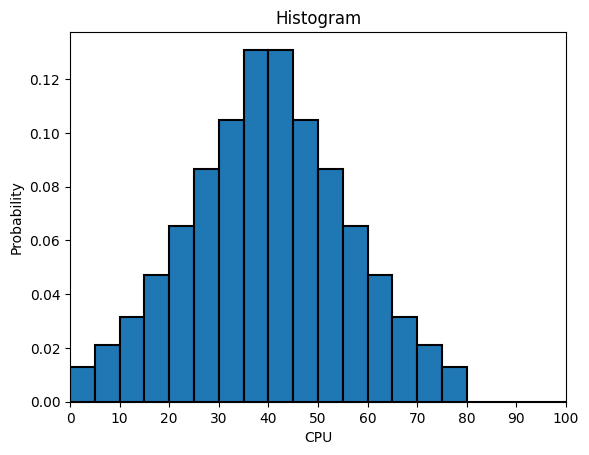

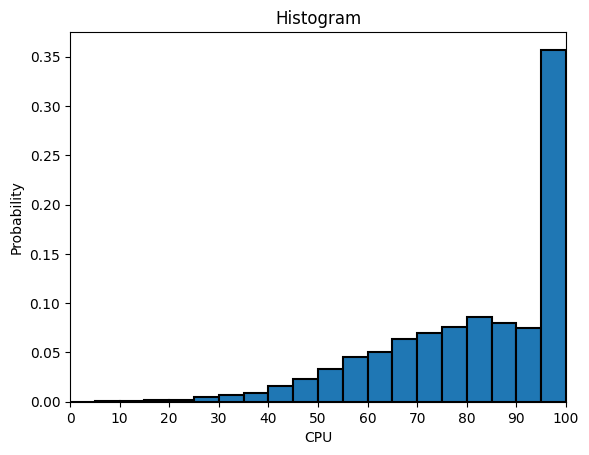

CollocationCost(carry_over_freq=20.23%, avg_carry_over=11.62%)
CollocationCost(carry_over_freq=19.67%, avg_carry_over=12.19%)


In [49]:
hist = Histogram.import_from(DATA_FILE)

hist.draw()
combined, costs = Histogram.collocate(hist, hist)
combined.draw()
for i, cost in enumerate(costs):
    print(cost)

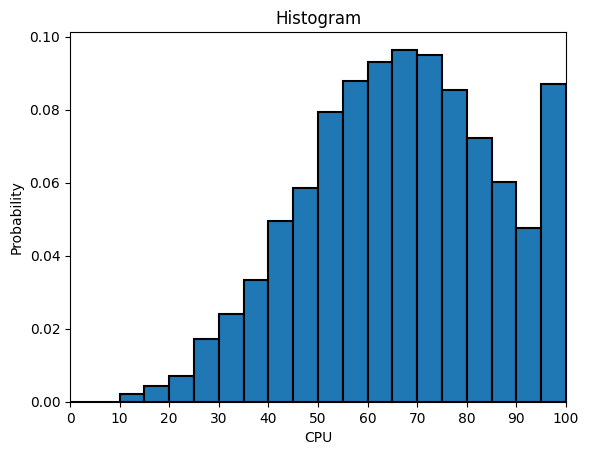

Process 0 average carry over CPU usage: CollocationCost(carry_over_freq=5.14%, avg_carry_over=6.48%)%
Process 1 average carry over CPU usage: CollocationCost(carry_over_freq=0.00%, avg_carry_over=0.00%)%


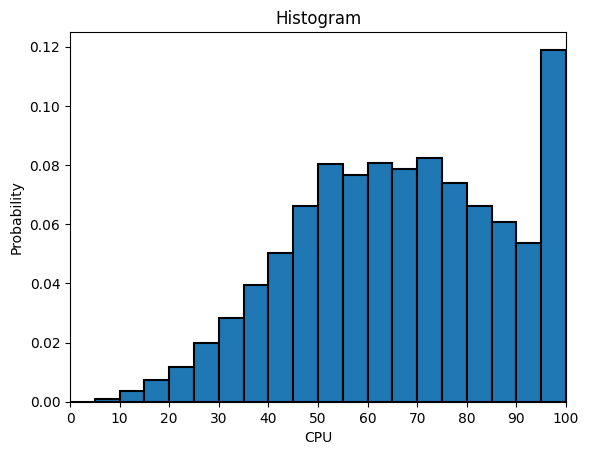

Process 0 average carry over CPU usage: CollocationCost(carry_over_freq=7.48%, avg_carry_over=8.01%)%
Process 1 average carry over CPU usage: CollocationCost(carry_over_freq=1.63%, avg_carry_over=2.53%)%


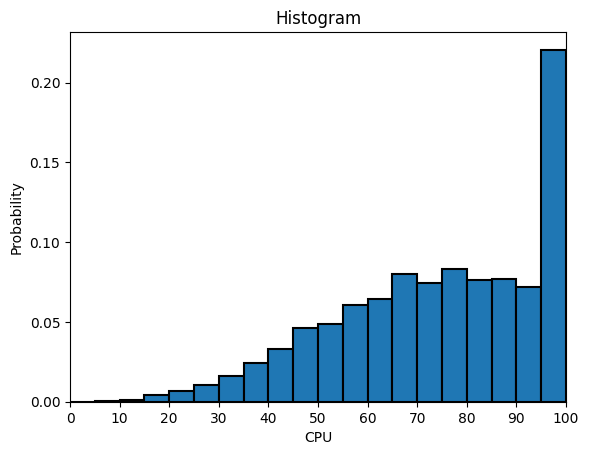

Process 0 average carry over CPU usage: CollocationCost(carry_over_freq=13.47%, avg_carry_over=9.71%)%
Process 1 average carry over CPU usage: CollocationCost(carry_over_freq=7.74%, avg_carry_over=3.86%)%


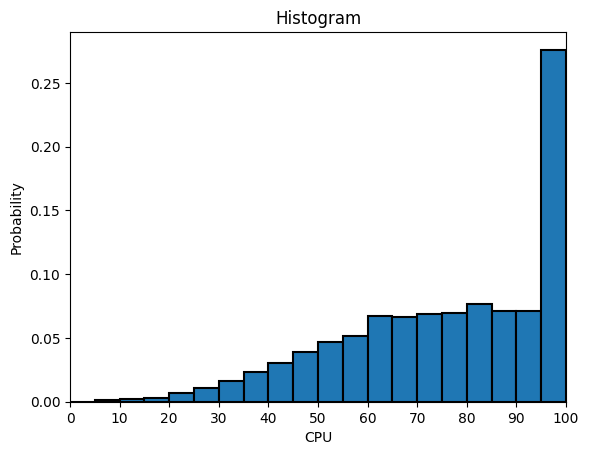

Process 0 average carry over CPU usage: CollocationCost(carry_over_freq=15.47%, avg_carry_over=10.34%)%
Process 1 average carry over CPU usage: CollocationCost(carry_over_freq=14.02%, avg_carry_over=7.02%)%


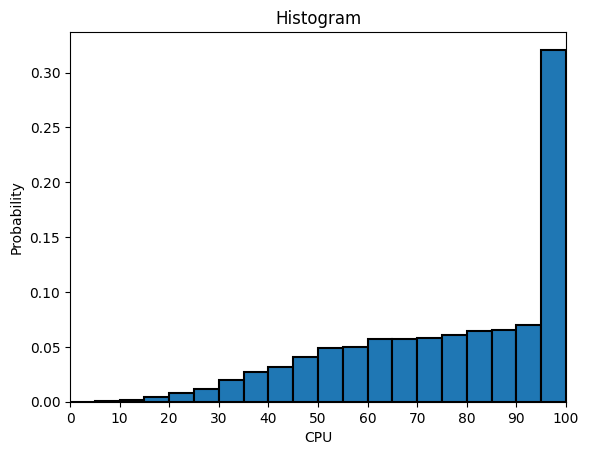

Process 0 average carry over CPU usage: CollocationCost(carry_over_freq=16.58%, avg_carry_over=11.43%)%
Process 1 average carry over CPU usage: CollocationCost(carry_over_freq=20.16%, avg_carry_over=9.07%)%


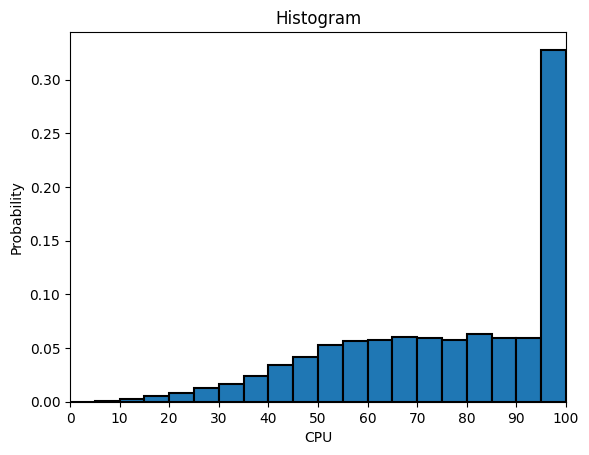

Process 0 average carry over CPU usage: CollocationCost(carry_over_freq=14.36%, avg_carry_over=11.18%)%
Process 1 average carry over CPU usage: CollocationCost(carry_over_freq=23.19%, avg_carry_over=11.65%)%


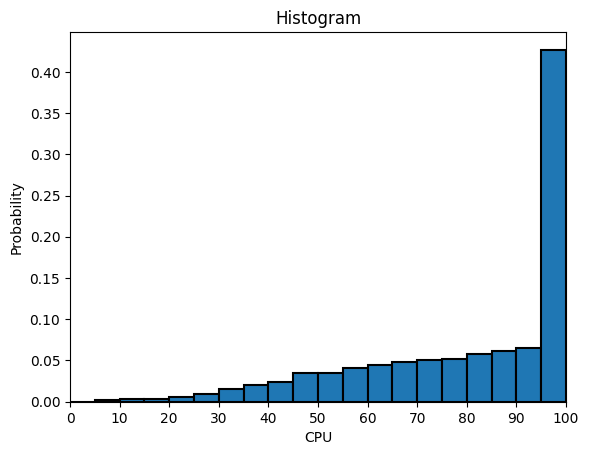

Process 0 average carry over CPU usage: CollocationCost(carry_over_freq=20.44%, avg_carry_over=11.58%)%
Process 1 average carry over CPU usage: CollocationCost(carry_over_freq=29.42%, avg_carry_over=15.57%)%


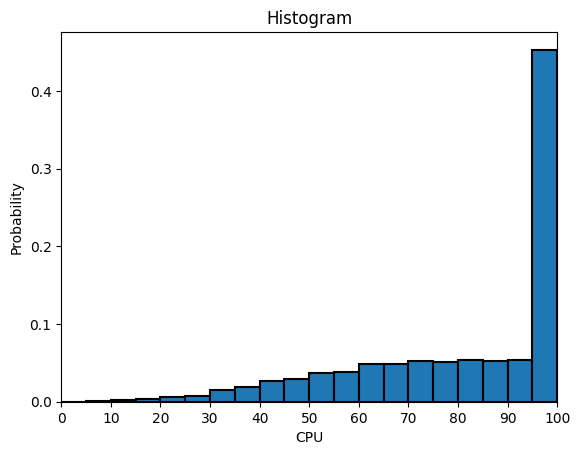

Process 0 average carry over CPU usage: CollocationCost(carry_over_freq=20.69%, avg_carry_over=12.74%)%
Process 1 average carry over CPU usage: CollocationCost(carry_over_freq=35.48%, avg_carry_over=22.79%)%


In [50]:
hist_first = Histogram.import_from(DATA_FILE)
for j in range(1, 9):
    hist_second = Histogram.import_from(f"histograms/uniform_{j}.txt")
    combined, costs = Histogram.collocate(hist_first, hist_second)
    combined.draw()
    for i, cost in enumerate(costs):
        print(f"Process {i} average carry over CPU usage: {cost}%")

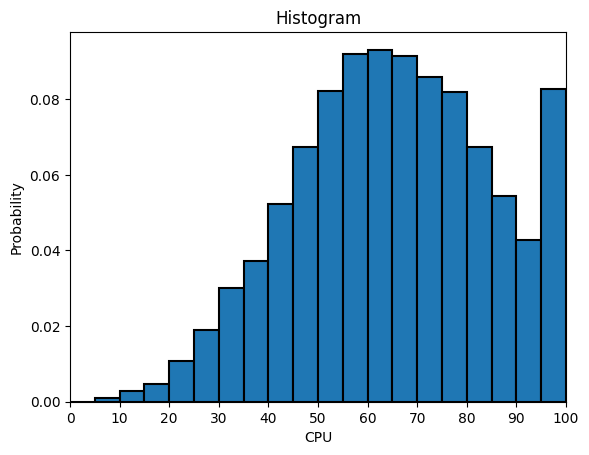

Process 0 average carry over CPU usage: CollocationCost(carry_over_freq=4.84%, avg_carry_over=7.00%)%
Process 1 average carry over CPU usage: CollocationCost(carry_over_freq=1.08%, avg_carry_over=3.34%)%


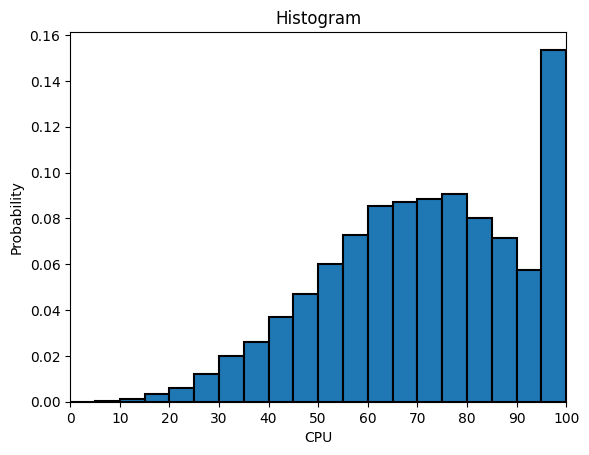

Process 0 average carry over CPU usage: CollocationCost(carry_over_freq=8.92%, avg_carry_over=8.41%)%
Process 1 average carry over CPU usage: CollocationCost(carry_over_freq=4.11%, avg_carry_over=5.09%)%


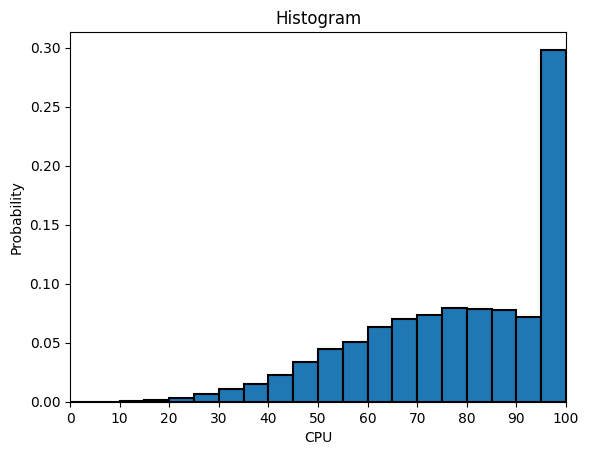

Process 0 average carry over CPU usage: CollocationCost(carry_over_freq=16.46%, avg_carry_over=11.09%)%
Process 1 average carry over CPU usage: CollocationCost(carry_over_freq=14.91%, avg_carry_over=9.56%)%


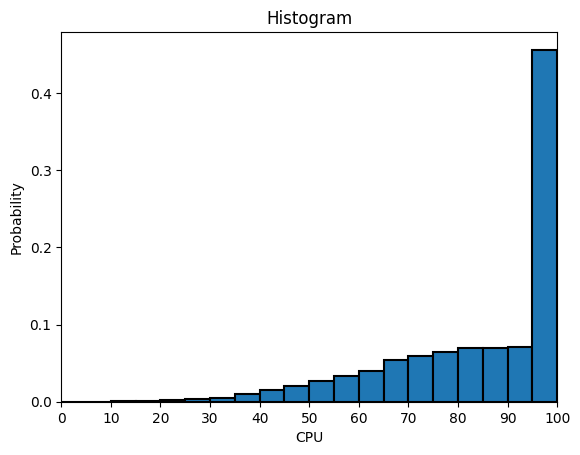

Process 0 average carry over CPU usage: CollocationCost(carry_over_freq=22.71%, avg_carry_over=11.88%)%
Process 1 average carry over CPU usage: CollocationCost(carry_over_freq=31.19%, avg_carry_over=16.70%)%


In [51]:
hist_first = Histogram.import_from(DATA_FILE)
for j in range(1, 5):
    hist_second = Histogram.import_from(f"histograms/normal_{j}.txt")
    combined, costs = Histogram.collocate(hist_first, hist_second)
    combined.draw()
    for i, cost in enumerate(costs):
        print(f"Process {i} average carry over CPU usage: {cost}%")